# RandomForest vs XGBoost on `hab_ndbc_merged.csv` for `isHarmful`

This notebook keeps the same feature exclusions as the earlier exploratory pass, but switches to a more defensible workflow:
- lock one random forest configuration and one XGBoost configuration ahead of the final test readout
- use a chronological train/validation/test split
- tune the decision threshold on the validation window only
- report test metrics once at the end

Primary goal for class `isHarmful = 1`:
- recall > 0.80
- precision > 0.30
- f1 > 0.30


In [6]:
%pip install xgboost scikit-learn matplotlib pandas numpy ipykernel


Note: you may need to restart the kernel to use updated packages.


In [7]:
# If needed, uncomment and run:
# %pip install scikit-learn matplotlib pandas numpy xgboost

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")


In [8]:
candidate_paths = [
    Path("../../hab_ndbc_merged.csv"),
    Path("../hab_ndbc_merged.csv"),
    Path("hab_ndbc_merged.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), candidate_paths[0])

df = pd.read_csv(DATA_PATH, parse_dates=["week_start", "sample_date"])
df = df.sort_values("week_start").reset_index(drop=True)

print(f"Loaded {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head()


Loaded ../../hab_ndbc_merged.csv
Shape: (3078, 36)


,week_start,station,sample_date,latitude,longitude,month,year,pda,temp,silicate,nitrate,avg_chloro,potential_bloom,sst_roll_14d,anom_roll_14d,sst_roc_3d,warm_degree_days_14d,above_avg,temp_lag1,temp_lag2,silicate_lag1,silicate_lag2,nitrate_lag1,nitrate_lag2,avg_chloro_lag1,avg_chloro_lag2,silicate_nitrate_ratio,isHarmful,station_id,wind_speed_mps,wave_height_m,dominant_period_s,mean_wave_dir_deg,atm_pressure_hpa,air_temp_c,sea_surface_temp_c
0,2017-01-02,Cal Poly Pier,2017-01-02,35.1702,-120.7407,1,2017,0.0000,10.0000,14.5145,14.6540,4.3600,0,13.0699,-0.6922,0.0453,0.0000,0,10.0000,10.0000,14.5145,14.5145,14.6540,14.6540,4.3600,4.3600,0.9905,0,46011,5.0540,2.2430,11.8800,304.5000,1014.8080,10.9250,12.9960
1,2017-01-02,Newport Beach Pier,2017-01-02,33.6061,-117.9311,1,2017,0.0000,14.2000,4.2200,2.5900,3.2000,0,14.7979,-0.2274,0.0527,0.0380,1,14.2000,14.2000,4.2200,4.2200,2.5900,2.5900,3.2000,3.2000,1.6293,0,46025,4.8650,1.1330,9.4010,246.1250,1012.3470,12.5530,14.5330
2,2017-01-02,Santa Monica Pier,2017-01-02,34.0080,-118.4990,1,2017,0.0000,15.8000,6.2890,4.1000,0.8000,0,14.7116,-0.0821,0.0760,0.4180,1,15.8000,15.8000,6.2890,6.2890,4.1000,4.1000,0.8000,0.8000,1.5339,0,46025,4.8650,1.1330,9.4010,246.1250,1012.3470,12.5530,14.5330
3,2017-01-02,Stearns Wharf,2017-01-02,34.4080,-119.6848,1,2017,0.0000,13.6000,6.2290,3.4980,0.8470,0,14.1456,-0.2447,0.0087,0.0000,0,13.6000,13.6000,6.2290,6.2290,3.4980,3.4980,0.8470,0.8470,1.7807,0,46053,8.0870,1.4980,10.5600,262.0830,1012.8830,NaN,NaN
4,2017-01-02,Scripps Pier,2017-01-02,32.8670,-117.2570,1,2017,0.0000,15.2000,2.1000,0.5400,0.8900,0,15.2582,-0.0635,0.0860,0.4340,1,15.2000,15.2000,2.1000,2.1000,0.5400,0.5400,0.8900,0.8900,3.8889,0,46086,6.3830,1.6750,12.7290,278.7500,1012.9670,12.9790,15.7630


In [9]:
target_col = "isHarmful"

target_summary = pd.DataFrame(
    {
        "count": df[target_col].value_counts().sort_index(),
        "rate": df[target_col].value_counts(normalize=True).sort_index(),
    }
)

print("Target distribution:")
display(target_summary)

print("Top missing columns:")
display(df.isna().sum().sort_values(ascending=False).head(12).to_frame("missing_rows"))


Target distribution:


,count,rate
isHarmful,,
0,2883,0.9366
1,195,0.0634


Top missing columns:


,missing_rows
silicate_nitrate_ratio,652
air_temp_c,631
sea_surface_temp_c,408
atm_pressure_hpa,341
wave_height_m,297
mean_wave_dir_deg,297
dominant_period_s,297
wind_speed_mps,257
latitude,0
sample_date,0


## Feature setup

The target is `isHarmful`. We intentionally drop:
- `pda` because it directly informed the harmful labeling
- `potential_bloom` because it is a near-target proxy in this merged file
- `week_start` and `sample_date` because we keep them only for chronological splitting and reporting
- `station_id` because `station` already captures site identity without imposing an ordinal code
- `latitude` and `longitude` because they are redundant once `station` is included
- `mean_wave_dir_deg` because it is a circular measurement that usually needs special encoding and can add noise when treated as a plain linear value


In [10]:
categorical_features = ["station"]

numeric_features = [
    "month",
    "year",
    "temp",
    "silicate",
    "nitrate",
    "avg_chloro",
    "sst_roll_14d",
    "anom_roll_14d",
    "sst_roc_3d",
    "warm_degree_days_14d",
    "above_avg",
    "temp_lag1",
    "temp_lag2",
    "silicate_lag1",
    "silicate_lag2",
    "nitrate_lag1",
    "nitrate_lag2",
    "avg_chloro_lag1",
    "avg_chloro_lag2",
    "silicate_nitrate_ratio",
    "wind_speed_mps",
    "wave_height_m",
    "dominant_period_s",
    "atm_pressure_hpa",
    "air_temp_c",
    "sea_surface_temp_c",
]

feature_cols = categorical_features + numeric_features
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

assert "pda" not in feature_cols
assert "potential_bloom" not in feature_cols

print(f"Feature columns: {len(feature_cols)}")
display(pd.DataFrame({"feature": feature_cols}))
display(X.head())


Feature columns: 27


,feature
0,station
1,month
2,year
3,temp
4,silicate
5,nitrate
6,avg_chloro
7,sst_roll_14d
8,anom_roll_14d
9,sst_roc_3d


,station,month,year,temp,silicate,nitrate,avg_chloro,sst_roll_14d,anom_roll_14d,sst_roc_3d,warm_degree_days_14d,above_avg,temp_lag1,temp_lag2,silicate_lag1,silicate_lag2,nitrate_lag1,nitrate_lag2,avg_chloro_lag1,avg_chloro_lag2,silicate_nitrate_ratio,wind_speed_mps,wave_height_m,dominant_period_s,atm_pressure_hpa,air_temp_c,sea_surface_temp_c
0,Cal Poly Pier,1,2017,10.0000,14.5145,14.6540,4.3600,13.0699,-0.6922,0.0453,0.0000,0,10.0000,10.0000,14.5145,14.5145,14.6540,14.6540,4.3600,4.3600,0.9905,5.0540,2.2430,11.8800,1014.8080,10.9250,12.9960
1,Newport Beach Pier,1,2017,14.2000,4.2200,2.5900,3.2000,14.7979,-0.2274,0.0527,0.0380,1,14.2000,14.2000,4.2200,4.2200,2.5900,2.5900,3.2000,3.2000,1.6293,4.8650,1.1330,9.4010,1012.3470,12.5530,14.5330
2,Santa Monica Pier,1,2017,15.8000,6.2890,4.1000,0.8000,14.7116,-0.0821,0.0760,0.4180,1,15.8000,15.8000,6.2890,6.2890,4.1000,4.1000,0.8000,0.8000,1.5339,4.8650,1.1330,9.4010,1012.3470,12.5530,14.5330
3,Stearns Wharf,1,2017,13.6000,6.2290,3.4980,0.8470,14.1456,-0.2447,0.0087,0.0000,0,13.6000,13.6000,6.2290,6.2290,3.4980,3.4980,0.8470,0.8470,1.7807,8.0870,1.4980,10.5600,1012.8830,NaN,NaN
4,Scripps Pier,1,2017,15.2000,2.1000,0.5400,0.8900,15.2582,-0.0635,0.0860,0.4340,1,15.2000,15.2000,2.1000,2.1000,0.5400,0.5400,0.8900,0.8900,3.8889,6.3830,1.6750,12.7290,1012.9670,12.9790,15.7630


## Chronological split

We use a chronological `70 / 15 / 15` split:
- train: oldest 70%
- validation: next 15% for threshold tuning only
- test: newest 15% for the final readout only


In [11]:
n_rows = len(df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_val), len(X_test)],
        "positive_count": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
        "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
        "start_week": [
            df.loc[: train_end - 1, "week_start"].min(),
            df.loc[train_end: val_end - 1, "week_start"].min(),
            df.loc[val_end:, "week_start"].min(),
        ],
        "end_week": [
            df.loc[: train_end - 1, "week_start"].max(),
            df.loc[train_end: val_end - 1, "week_start"].max(),
            df.loc[val_end:, "week_start"].max(),
        ],
    },
    index=["train", "validation", "test"],
)

imbalance_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"Train negative/positive ratio: {imbalance_ratio:0.2f}:1")
display(split_summary)


Train negative/positive ratio: 18.94:1


,rows,positive_count,positive_rate,start_week,end_week
train,2154,108,0.0501,2017-01-02,2023-05-29
validation,462,20,0.0433,2023-05-29,2024-09-09
test,462,67,0.1450,2024-09-09,2026-03-23


## Locked model configurations

These are fixed before the final test readout:
- random forest: the recall-heavy weighted setting from the exploratory pass
- XGBoost: the strongest exploratory XGBoost configuration that previously cleared the target set on the old test-tuned workflow

That keeps the strict pass focused on threshold tuning rather than searching a large model family on the final split.


In [12]:
TARGETS = {"recall": 0.80, "precision": 0.30, "f1": 0.30}


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
            (
                "numeric",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                numeric_features,
            ),
        ]
    )



def build_rf_pipeline():
    model = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight={0: 1.0, 1: 100.0},
    )
    return Pipeline(steps=[("preprocess", build_preprocessor()), ("model", model)])



def build_xgb_pipeline():
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=float(imbalance_ratio * 2.2),
        n_jobs=1,
        tree_method="hist",
    )
    return Pipeline(steps=[("preprocess", build_preprocessor()), ("model", model)])



def summarize_predictions(y_true, y_pred, y_score):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
        "predicted_positives": int(y_pred.sum()),
    }



def threshold_sweep(model_family, y_true, y_score):
    rows = []
    for threshold in np.arange(0.01, 0.31, 0.01):
        y_pred = (y_score >= threshold).astype(int)
        metrics = summarize_predictions(y_true, y_pred, y_score)
        target_count = sum(metrics[name] > value for name, value in TARGETS.items())
        rows.append(
            {
                "model_family": model_family,
                "threshold": round(float(threshold), 2),
                **metrics,
                "target_count": int(target_count),
                "meets_all_targets": bool(target_count == len(TARGETS)),
            }
        )

    return pd.DataFrame(rows).sort_values(
        ["meets_all_targets", "target_count", "recall", "precision", "f1", "average_precision"],
        ascending=False,
    ).reset_index(drop=True)


models = {
    "random_forest": build_rf_pipeline(),
    "xgboost": build_xgb_pipeline(),
}

model_descriptions = pd.DataFrame(
    [
        {
            "model_family": "random_forest",
            "configuration": "class_weight={0: 1.0, 1: 100.0}, n_estimators=500, min_samples_leaf=5",
        },
        {
            "model_family": "xgboost",
            "configuration": (
                f"scale_pos_weight={imbalance_ratio * 2.2:0.2f}, max_depth=3, learning_rate=0.03, "
                "min_child_weight=5, subsample=0.9, colsample_bytree=0.8, n_estimators=500"
            ),
        },
    ]
)

model_descriptions


,model_family,configuration
0,random_forest,"class_weight={0: 1.0, 1: 100.0}, n_estimators=..."
1,xgboost,"scale_pos_weight=41.68, max_depth=3, learning_..."


## Fit on train and tune threshold on validation

This is the critical strict step. We fit each locked model on the training window, score the validation window, and choose the threshold from validation only.


In [13]:
validation_rows = []
validation_scores = {}
fitted_models = {}

for family, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[family] = pipeline

    y_val_score = pipeline.predict_proba(X_val)[:, 1]
    validation_scores[family] = y_val_score

    y_val_pred_default = (y_val_score >= 0.50).astype(int)
    metrics = summarize_predictions(y_val, y_val_pred_default, y_val_score)
    validation_rows.append(
        {
            "model_family": family,
            "threshold": 0.50,
            **metrics,
        }
    )

validation_default_results = pd.DataFrame(validation_rows).sort_values(
    ["recall", "precision", "f1"],
    ascending=False,
).reset_index(drop=True)

validation_default_results


,model_family,threshold,precision,recall,f1,balanced_accuracy,roc_auc,average_precision,predicted_positives
0,xgboost,0.5000,0.0714,0.1500,0.0968,0.5309,0.7536,0.0927,42
1,random_forest,0.5000,0.1538,0.1000,0.1212,0.5376,0.7331,0.0897,13


In [14]:
threshold_tables = []
selected_threshold_rows = []

for family in ["random_forest", "xgboost"]:
    table = threshold_sweep(family, y_val, validation_scores[family])
    threshold_tables.append(table)

    print(f"Top validation threshold rows for {family}:")
    display(table.head(12))

    selected_threshold_rows.append(table.iloc[0].copy())

validation_threshold_results = pd.concat(threshold_tables, ignore_index=True)
selected_thresholds = pd.DataFrame(selected_threshold_rows).sort_values(
    ["meets_all_targets", "target_count", "recall", "precision", "f1"],
    ascending=False,
).reset_index(drop=True)

selected_thresholds


Top validation threshold rows for random_forest:


,model_family,threshold,precision,recall,f1,balanced_accuracy,roc_auc,average_precision,predicted_positives,target_count,meets_all_targets
0,random_forest,0.0300,0.0687,1.0000,0.1286,0.6934,0.7331,0.0897,291,1,False
1,random_forest,0.0200,0.0635,1.0000,0.1194,0.6663,0.7331,0.0897,315,1,False
2,random_forest,0.0100,0.0573,1.0000,0.1084,0.6278,0.7331,0.0897,349,1,False
3,random_forest,0.0400,0.0691,0.9500,0.1288,0.6854,0.7331,0.0897,275,1,False
4,random_forest,0.0600,0.0779,0.9000,0.1434,0.7090,0.7331,0.0897,231,1,False
5,random_forest,0.0500,0.0714,0.9000,0.1324,0.6853,0.7331,0.0897,252,1,False
6,random_forest,0.0700,0.0744,0.8000,0.1362,0.6749,0.7331,0.0897,215,0,False
7,random_forest,0.1100,0.0926,0.7500,0.1648,0.7087,0.7331,0.0897,162,0,False
8,random_forest,0.1000,0.0882,0.7500,0.1579,0.6997,0.7331,0.0897,170,0,False
9,random_forest,0.0900,0.0829,0.7500,0.1493,0.6872,0.7331,0.0897,181,0,False


Top validation threshold rows for xgboost:


,model_family,threshold,precision,recall,f1,balanced_accuracy,roc_auc,average_precision,predicted_positives,target_count,meets_all_targets
0,xgboost,0.0300,0.0749,1.0000,0.1394,0.7206,0.7536,0.0927,267,1,False
1,xgboost,0.0200,0.0697,1.0000,0.1303,0.6980,0.7536,0.0927,287,1,False
2,xgboost,0.0100,0.0608,1.0000,0.1146,0.6505,0.7536,0.0927,329,1,False
3,xgboost,0.0500,0.0795,0.9500,0.1467,0.7261,0.7536,0.0927,239,1,False
4,xgboost,0.0400,0.0754,0.9500,0.1397,0.7114,0.7536,0.0927,252,1,False
5,xgboost,0.0900,0.0874,0.9000,0.1593,0.7373,0.7536,0.0927,206,1,False
6,xgboost,0.0800,0.0849,0.9000,0.1552,0.7305,0.7536,0.0927,212,1,False
7,xgboost,0.0700,0.0818,0.9000,0.1500,0.7215,0.7536,0.0927,220,1,False
8,xgboost,0.0600,0.0793,0.9000,0.1457,0.7136,0.7536,0.0927,227,1,False
9,xgboost,0.1000,0.0867,0.8500,0.1574,0.7225,0.7536,0.0927,196,1,False


,model_family,threshold,precision,recall,f1,balanced_accuracy,roc_auc,average_precision,predicted_positives,target_count,meets_all_targets
0,xgboost,0.0300,0.0749,1.0000,0.1394,0.7206,0.7536,0.0927,267,1,False
1,random_forest,0.0300,0.0687,1.0000,0.1286,0.6934,0.7331,0.0897,291,1,False


## Final test evaluation

Now we freeze each model family at its validation-selected threshold and evaluate the test window exactly once.


xgboost | validation-selected threshold=0.03 | test recall=0.896 | test precision=0.297 | test f1=0.446
              precision    recall  f1-score   support

           0     0.9731    0.6405    0.7725       395
           1     0.2970    0.8955    0.4461        67

    accuracy                         0.6775       462
   macro avg     0.6351    0.7680    0.6093       462
weighted avg     0.8750    0.6775    0.7252       462



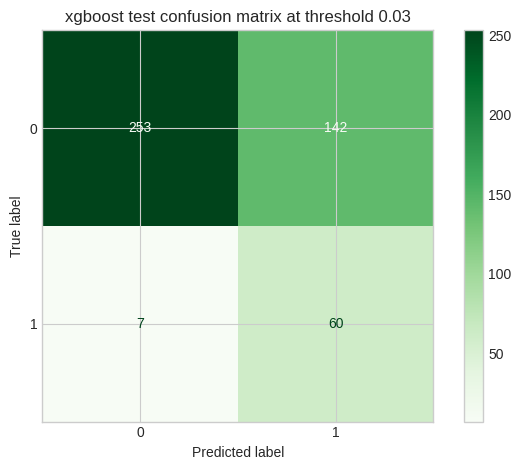

random_forest | validation-selected threshold=0.03 | test recall=0.955 | test precision=0.229 | test f1=0.370
              precision    recall  f1-score   support

           0     0.9836    0.4557    0.6228       395
           1     0.2294    0.9552    0.3699        67

    accuracy                         0.5281       462
   macro avg     0.6065    0.7055    0.4964       462
weighted avg     0.8742    0.5281    0.5862       462



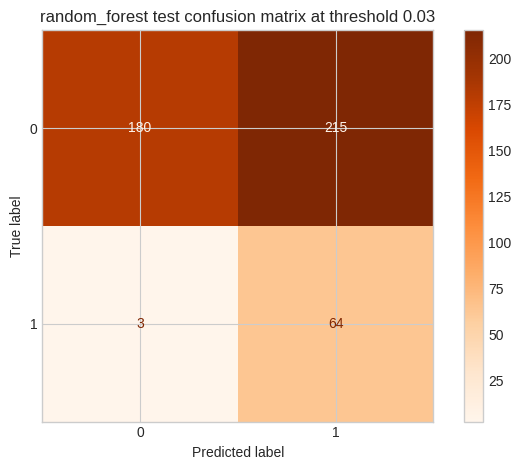

,model_family,threshold,precision,recall,f1,balanced_accuracy,roc_auc,average_precision,predicted_positives,target_count,meets_all_targets
0,xgboost,0.0300,0.2970,0.8955,0.4461,0.7680,0.8487,0.4246,202,2,False
1,random_forest,0.0300,0.2294,0.9552,0.3699,0.7055,0.8194,0.3894,279,2,False


In [15]:
test_rows = []

for row in selected_thresholds.itertuples(index=False):
    family = row.model_family
    threshold = float(row.threshold)
    model = fitted_models[family]

    y_test_score = model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_score >= threshold).astype(int)
    metrics = summarize_predictions(y_test, y_test_pred, y_test_score)
    target_count = sum(metrics[name] > value for name, value in TARGETS.items())

    test_rows.append(
        {
            "model_family": family,
            "threshold": threshold,
            **metrics,
            "target_count": target_count,
            "meets_all_targets": bool(target_count == len(TARGETS)),
        }
    )

    print(
        f"{family} | validation-selected threshold={threshold:0.2f} | "
        f"test recall={metrics['recall']:0.3f} | test precision={metrics['precision']:0.3f} | test f1={metrics['f1']:0.3f}"
    )
    print(classification_report(y_test, y_test_pred, digits=4))

    cmap = "Oranges" if family == "random_forest" else "Greens"
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap=cmap)
    plt.title(f"{family} test confusion matrix at threshold {threshold:0.2f}")
    plt.tight_layout()
    plt.show()

final_test_results = pd.DataFrame(test_rows).sort_values(
    ["target_count", "precision", "f1", "recall"],
    ascending=False,
).reset_index(drop=True)

final_test_results


## Best overall model in the strict workflow

The table below is the test-set comparison from the validation-only tuning workflow.


model_family           xgboost
threshold               0.0300
precision               0.2970
recall                  0.8955
f1                      0.4461
balanced_accuracy       0.7680
roc_auc                 0.8487
average_precision       0.4246
predicted_positives        202
target_count                 2
meets_all_targets        False
Name: 0, dtype: object


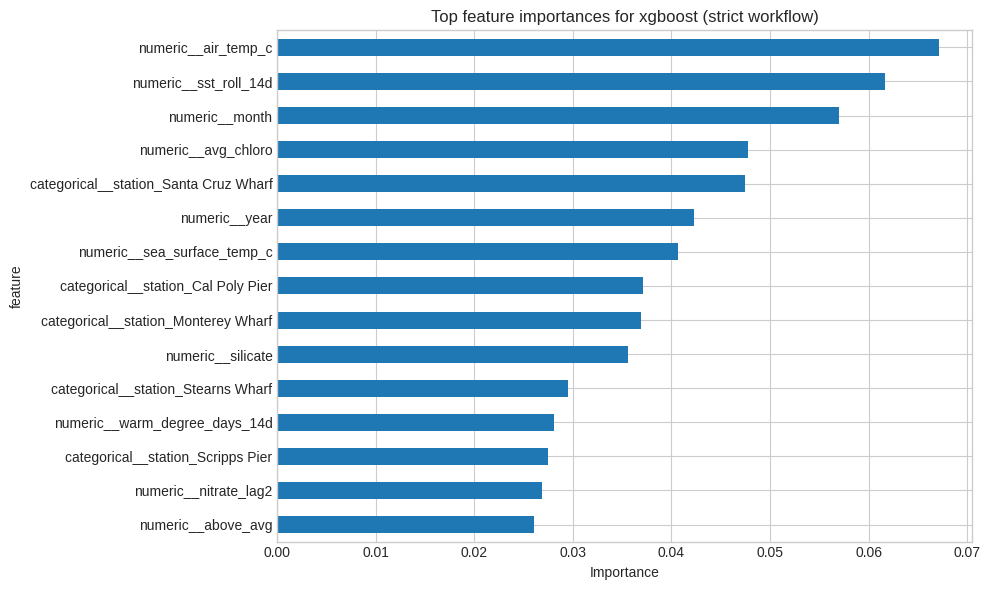

,feature,importance
0,numeric__air_temp_c,0.0672
1,numeric__sst_roll_14d,0.0617
2,numeric__month,0.0570
3,numeric__avg_chloro,0.0478
4,categorical__station_Santa Cruz Wharf,0.0475
5,numeric__year,0.0422
6,numeric__sea_surface_temp_c,0.0407
7,categorical__station_Cal Poly Pier,0.0371
8,categorical__station_Monterey Wharf,0.0369
9,numeric__silicate,0.0356


In [16]:
best_overall = final_test_results.sort_values(
    ["target_count", "precision", "f1", "recall"],
    ascending=False,
).iloc[0]

best_family = best_overall["model_family"]
best_threshold = float(best_overall["threshold"])
best_model = fitted_models[best_family]

print(best_overall)

feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_features = importance_df.head(15).sort_values("importance")
ax = top_features.plot(kind="barh", x="feature", y="importance", figsize=(10, 6), legend=False)
ax.set_title(f"Top feature importances for {best_family} (strict workflow)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importance_df.head(15)


## Compare and contrast: Random forest vs XGBoost

This section turns the final strict-workflow test results into a side-by-side comparison.
Use it to answer two separate questions:
- Which model catches more harmful blooms? Look at `recall`.
- Which model gives the better overall tradeoff? Look at `precision`, `f1`, `balanced_accuracy`, and `average_precision` together.


In [17]:
comparison_table = final_test_results.set_index("model_family").copy()

display(
    comparison_table[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "average_precision",
            "roc_auc",
            "predicted_positives",
        ]
    ]
)

rf = comparison_table.loc["random_forest"]
xgb = comparison_table.loc["xgboost"]

summary_rows = [
    {
        "question": "Higher recall for harmful blooms",
        "winner": "random_forest" if rf["recall"] > xgb["recall"] else "xgboost",
        "why": f"RF recall={rf['recall']:.3f}, XGB recall={xgb['recall']:.3f}",
    },
    {
        "question": "Higher precision",
        "winner": "random_forest" if rf["precision"] > xgb["precision"] else "xgboost",
        "why": f"RF precision={rf['precision']:.3f}, XGB precision={xgb['precision']:.3f}",
    },
    {
        "question": "Higher F1",
        "winner": "random_forest" if rf["f1"] > xgb["f1"] else "xgboost",
        "why": f"RF f1={rf['f1']:.3f}, XGB f1={xgb['f1']:.3f}",
    },
    {
        "question": "Higher balanced accuracy",
        "winner": "random_forest" if rf["balanced_accuracy"] > xgb["balanced_accuracy"] else "xgboost",
        "why": f"RF balanced_accuracy={rf['balanced_accuracy']:.3f}, XGB balanced_accuracy={xgb['balanced_accuracy']:.3f}",
    },
    {
        "question": "Higher average precision",
        "winner": "random_forest" if rf["average_precision"] > xgb["average_precision"] else "xgboost",
        "why": f"RF average_precision={rf['average_precision']:.3f}, XGB average_precision={xgb['average_precision']:.3f}",
    },
]

display(pd.DataFrame(summary_rows))

print("Random forest:")
print(
    f"- Strongest at recall: it catches more harmful blooms ({rf['recall']:.3f}), "
    f"but with lower precision ({rf['precision']:.3f}) and lower f1 ({rf['f1']:.3f})."
)
print(
    f"- It predicts harmful more often ({int(rf['predicted_positives'])} positives on the test window), "
    "so it acts like the more aggressive alarm system."
)

print("\nXGBoost:")
print(
    f"- Still very strong on recall ({xgb['recall']:.3f}), but with better precision ({xgb['precision']:.3f}) "
    f"and better f1 ({xgb['f1']:.3f}) than random forest."
)
print(
    f"- It predicts fewer harmful cases ({int(xgb['predicted_positives'])} positives on the test window), "
    "so it is the more selective model."
)

print("\nTakeaway:")
print(
    "- If the main priority is minimizing missed harmful blooms, random forest is stronger on recall."
)
print(
    "- If the main priority is the better overall precision-recall tradeoff, XGBoost is the stronger model in this notebook."
)


,threshold,precision,recall,f1,balanced_accuracy,average_precision,roc_auc,predicted_positives
model_family,,,,,,,,
xgboost,0.0300,0.2970,0.8955,0.4461,0.7680,0.4246,0.8487,202
random_forest,0.0300,0.2294,0.9552,0.3699,0.7055,0.3894,0.8194,279


,question,winner,why
0,Higher recall for harmful blooms,random_forest,"RF recall=0.955, XGB recall=0.896"
1,Higher precision,xgboost,"RF precision=0.229, XGB precision=0.297"
2,Higher F1,xgboost,"RF f1=0.370, XGB f1=0.446"
3,Higher balanced accuracy,xgboost,"RF balanced_accuracy=0.705, XGB balanced_accur..."
4,Higher average precision,xgboost,"RF average_precision=0.389, XGB average_precis..."


Random forest:
- Strongest at recall: it catches more harmful blooms (0.955), but with lower precision (0.229) and lower f1 (0.370).
- It predicts harmful more often (279 positives on the test window), so it acts like the more aggressive alarm system.

XGBoost:
- Still very strong on recall (0.896), but with better precision (0.297) and better f1 (0.446) than random forest.
- It predicts fewer harmful cases (202 positives on the test window), so it is the more selective model.

Takeaway:
- If the main priority is minimizing missed harmful blooms, random forest is stronger on recall.
- If the main priority is the better overall precision-recall tradeoff, XGBoost is the stronger model in this notebook.


## Reading the strict results

This workflow is more honest than the exploratory pass, but it is also harsher:
- the validation slice is a specific later time window with relatively few positives
- threshold selection is no longer allowed to look at the final test window
- if the strict test metrics are worse than the exploratory metrics, that is expected and informative rather than a failure
